Real-Time Credit Risk Simulation

Lightweight, real-time credit risk analysis pipeline that simulates event ingestion, processes streaming data in pandas, applies logistic regression for prediction, and generates actionable business recommendations.

Sets up the environment and imports `run_pipeline()`.

Checks if the output parquet file exists and deletes it to ensure a fresh pipeline run.

Prints a message to indicate whether the file was removed or not.


In [1]:
import sys
import pandas as pd
import threading
import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

# -----------------------------
# Add project root to sys.path for module imports
# -----------------------------
root = "/Users/phillipsmith/Desktop/pythonProjects/real-time-credit-risk-simulation"
sys.path.append(root)

# -----------------------------
# Import external python modules
# -----------------------------

from pathlib import Path
from src.pipeline import run_pipeline
from src.viz.plots import Plots
from src.preprocessing import data_transformations

# -----------------------------
# Display full dataframes
# -----------------------------

pd.set_option('display.max_rows', None) # reset_option to compact dataframe view
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6f}'.format)

# -----------------------------
# Define path to processed parquet file
# -----------------------------
file_path = Path(
    '/Users/phillipsmith/Desktop/pythonProjects/real-time-credit-risk-simulation/src/data/processed/processed_df.parquet'
)

# -----------------------------
# Delete existing parquet file for a fresh execution
# -----------------------------
if file_path.exists():
    file_path.unlink()
    print(f"Deleted existing file: {file_path}", flush=True)
else:
    print("No existing parquet file found. Continuing...", flush=True)

Deleted existing file: /Users/phillipsmith/Desktop/pythonProjects/real-time-credit-risk-simulation/src/data/processed/processed_df.parquet


Runs `run_pipeline()` in a separate thread so the notebook can monitor progress in real time.

Continuously reads the output parquet file and prints changes to the DataFrame whenever new events are added.

In [2]:
# -----------------------------
# Initialize variables
# -----------------------------
previous_shape = (0, 0)
current_df = pd.DataFrame(columns=[])

# -----------------------------
# Start pipeline in a separate thread
# -----------------------------
pipeline_thread = threading.Thread(target=run_pipeline, daemon=True)
pipeline_thread.start()
print("Monitoring parquet file for updates...\n")

# -----------------------------
# Real-time monitoring loop
# -----------------------------
while pipeline_thread.is_alive():
    if file_path.exists():
        try:
            df = pd.read_parquet(file_path, engine='fastparquet')
            if not df.empty and df.shape != previous_shape:
                previous_shape = df.shape
        except Exception:
            pass
    time.sleep(0.05)

# -----------------------------
# Wait for pipeline thread to finish
# -----------------------------
pipeline_thread.join()

# -----------------------------
# Initialize final DataFrame as df
# -----------------------------
if file_path.exists():
    sns.set_theme()
    df = pd.read_parquet(file_path, engine='fastparquet')
    print(f"Initial DataFrame shape: {df.shape}\n")
else:
    print("Pipeline finished but file was not found.")

Monitoring parquet file for updates...

Event producing has initiated.
Event consuming has initiated.

Processing is complete.

Initial DataFrame shape: (45063, 8)



EDA, visualizations, and transformations are applied to each variable in the dataset as needed.

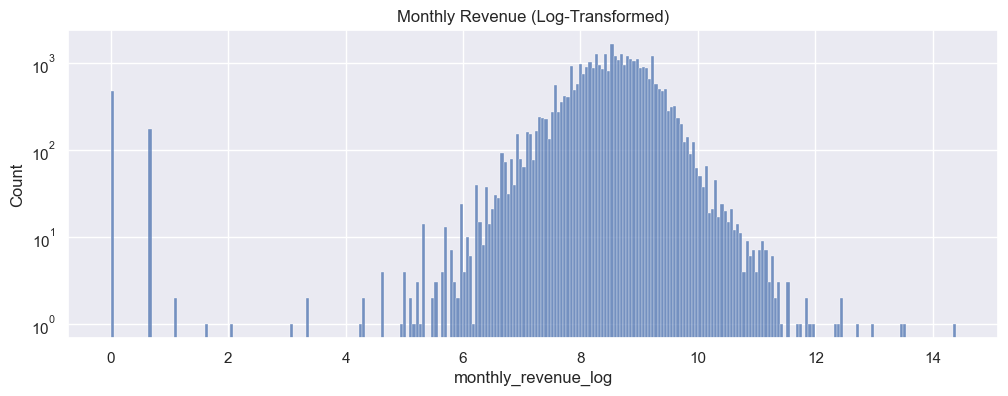

In [3]:
"""MONTHLY REVENUE"""

# Create the bins
monthly_revenue_raw = df[['monthly_revenue']].copy()

# Create revenue bins and labels
revenue_bins = [0, 5000, 10000, 15000, 20000, 25000, 50000, 100000, 999999999]
revenue_labels = ['0-5k', '5k-10k', '10k-15k', '15k-20k', '20k-25k', '25k-50k', '50k-100k', '100k+']

# Cut each row into its corresponding bin
monthly_revenue_raw['revenue_bin'] = pd.cut(monthly_revenue_raw['monthly_revenue'], 
                                            bins=revenue_bins, 
                                            labels=revenue_labels, 
                                            include_lowest=True)

# Add empty value category
monthly_revenue_raw['revenue_bin'] = (monthly_revenue_raw['revenue_bin'].cat.add_categories('NaN').fillna('NaN'))

# Display dataframe
monthly_revenue_raw.head()

"""Histogram Plot"""
x_var = 'revenue_bin'
plt.figure(figsize=(12,4))
# plt.title("Monthly Revenue (Binned)")
# sns.histplot(data=monthly_revenue_raw, x=x_var, log=True)

"""Log Transform Distribution"""
df['monthly_revenue_log'] = np.log1p(df['monthly_revenue'])
plt.title("Monthly Revenue (Log-Transformed)")
plt.yscale('log')
sns.histplot(df['monthly_revenue_log'])

df['revenue_missing'] = df['monthly_revenue'].isna().astype(int)


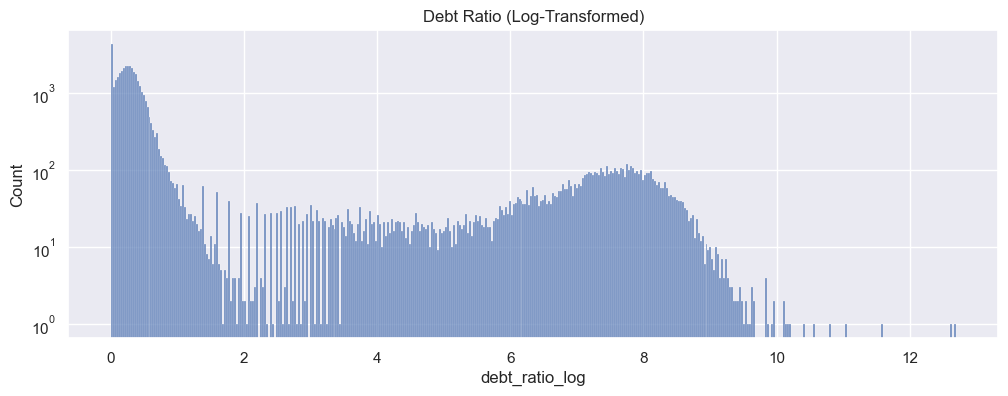

In [4]:
"""DEBT RATIO"""

# Create the bins
debt_ratio_raw = df[['debt_ratio']].copy()

# Create debt ratio bins and labels
debt_ratio_bins = [0, 1, 10, 50, 100, 500, 1000, 5000, 10000, 25000, 999999999]
debt_ratio_labels = ['0-1', '1-10', '10-50', '50-100', '100-500', '500-1000', '1000-5000', '5000-10000', '10000-25000', '25000+']

# Cut each row into its corresponding bin
debt_ratio_raw['debt_ratio_bin'] = pd.cut(debt_ratio_raw['debt_ratio'], 
                                            bins=debt_ratio_bins, 
                                            labels=debt_ratio_labels, 
                                            include_lowest=True)

# Add empty value category
debt_ratio_raw['debt_ratio_bin'] = (debt_ratio_raw['debt_ratio_bin'].cat.add_categories('NaN').fillna('NaN'))

# Display dataframe
debt_ratio_raw.head()

"""Histogram Plot"""
x_var = 'debt_ratio'
plt.figure(figsize=(12,4))
# plt.title("Debt Ratio (Binned)")
# sns.histplot(data=debt_ratio_raw, x=x_var, log=True)

"""Log Transform Distribution"""
df['debt_ratio_log'] = np.log1p(df['debt_ratio'])
plt.title("Debt Ratio (Log-Transformed)")
plt.yscale('log')
sns.histplot(df['debt_ratio_log'])

df['debt_ratio_missing'] = df['debt_ratio'].isna().astype(int)

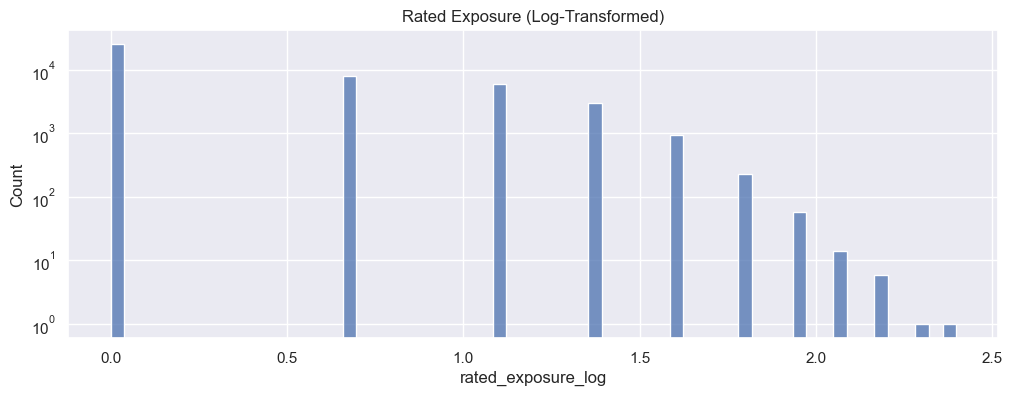

In [5]:
"""RATED EXPOSURE"""

# Create the bins
rated_exposure_raw = df[['rated_exposure']].copy()

# Create rated exposure bins and labels
rated_exposure_bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 100]
rated_exposure_labels = ['0-1', '1-2', '2-3', '3-4', '4-5', '5-6', '6-7', '7-8', '8-9', '9-10', '10-100']

# Cut each row into its corresponding bin
rated_exposure_raw['rated_exposure_bin'] = pd.cut(rated_exposure_raw['rated_exposure'], 
                                            bins=rated_exposure_bins, 
                                            labels=rated_exposure_labels, 
                                            include_lowest=True)

# Add empty value category
rated_exposure_raw['rated_exposure_bin'] = (rated_exposure_raw['rated_exposure_bin'].cat.add_categories('NaN').fillna('NaN'))

# Display dataframe
rated_exposure_raw.head()

"""Histogram Plot"""
x_var = 'rated_exposure'
plt.figure(figsize=(12,4))
# plt.title("Rated Exposure (Binned)")
# sns.histplot(data=rated_exposure_raw, x=x_var, log=True)

"""Log Transform Distribution"""
df['rated_exposure_log'] = np.log1p(df['rated_exposure'])
plt.title("Rated Exposure (Log-Transformed)")
plt.yscale('log')
sns.histplot(df['rated_exposure_log'])

df['rated_exposure_missing'] = df['rated_exposure'].isna().astype(int)

<Axes: title={'center': 'Overdue Severity (Log-Transformed)'}, xlabel='overdue_severity_log', ylabel='Count'>

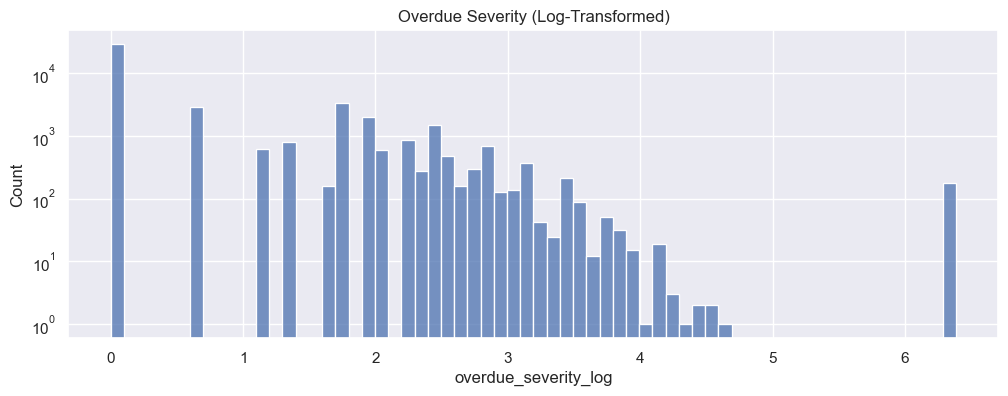

In [15]:
"""OVERDUE DAYS"""

low = 1
med = 2
high = 3
critical = 5

df['overdue_severity'] = (df['overdue_30_59_days'] * low) + (df['overdue_60_89_days'] * med) + (df['overdue_90_plus_days'] * high) + (df['serious_delinquencies_past_2_years'] * critical)

"""Log Transform Distribution"""
df['overdue_severity_log'] = np.log1p(df['overdue_severity'])
plt.figure(figsize=(12,4))
plt.title("Overdue Severity (Log-Transformed)")
plt.yscale('log')
sns.histplot(df['overdue_severity_log'])

Incorporate inter-quartile range (IQR) analysis to identify and handle outliers in the dataset, ensuring that the model is not skewed by extreme values.

In [16]:
"""MONTHLY REVENUE OUTLIER"""
Q1 = df['monthly_revenue'].quantile(0.25) # low outlier
Q3 = df['monthly_revenue'].quantile(0.75) # high outlier
IQR = Q3 - Q1
df['revenue_outlier'] = ((df['monthly_revenue'] < Q1 - 1.5*IQR) | 
                         (df['monthly_revenue'] > Q3 + 1.5*IQR)).astype(int)

"""DEBT RATIO OUTLIER"""
Q1 = df['debt_ratio'].quantile(0.25)
Q3 = df['debt_ratio'].quantile(0.75)
IQR = Q3 - Q1
df['debt_ratio_outlier'] = ((df['debt_ratio'] < Q1 - 1.5*IQR) | 
                         (df['debt_ratio'] > Q3 + 1.5*IQR)).astype(int)

"""RATED EXPOSURE OUTLIER"""
Q1 = df['rated_exposure'].quantile(0.25)
Q3 = df['rated_exposure'].quantile(0.75)
IQR = Q3 - Q1
df['rated_exposure_outlier'] = ((df['rated_exposure'] < Q1 - 1.5*IQR) | 
                         (df['rated_exposure'] > Q3 + 1.5*IQR)).astype(int)

"""OVERDUE SEVERITY OUTLIER"""
Q1 = df['overdue_severity'].quantile(0.25)
Q3 = df['overdue_severity'].quantile(0.75)
IQR = Q3 - Q1
df['overdue_severity_outlier'] = ((df['overdue_severity'] < Q1 - 1.5*IQR) | 
                         (df['overdue_severity'] > Q3 + 1.5*IQR)).astype(int)

Prepares the data for modeling by handling missing values, encoding categorical variables, and scaling features.

In [17]:
analysis_df = df[[
    'age', 
    'monthly_revenue', 
    'debt_ratio', 
    'rated_exposure', 
    'monthly_revenue_log', 
    'debt_ratio_log', 
    'rated_exposure_log', 
    'overdue_severity',
    'revenue_missing',
    'debt_ratio_missing',
    'rated_exposure_missing',
    'revenue_outlier',
    'debt_ratio_outlier',
    'rated_exposure_outlier',
    'overdue_severity_outlier'
    ]].copy()

analysis_df.head()

,age,monthly_revenue,debt_ratio,rated_exposure,monthly_revenue_log,debt_ratio_log,rated_exposure_log,overdue_severity,revenue_missing,debt_ratio_missing,rated_exposure_missing,revenue_outlier,debt_ratio_outlier,rated_exposure_outlier,overdue_severity_outlier
0,64.000000,8158.000000,0.249908,0.000000,9.006877,0.223070,0.000000,0.000000,0,0,0,0,0,0,0
1,58.000000,NaN,3870.000000,0.000000,NaN,8.261268,0.000000,0.000000,1,0,0,0,1,0,0
2,41.000000,6666.000000,0.456127,0.000000,8.804925,0.375780,0.000000,0.000000,0,0,0,0,0,0,0
3,43.000000,10500.000000,0.000190,2.000000,9.259226,0.000190,1.098612,0.000000,0,0,0,0,0,0,0
4,49.000000,400.000000,0.271820,0.000000,5.993961,0.240449,0.000000,5.000000,0,0,0,0,0,0,0


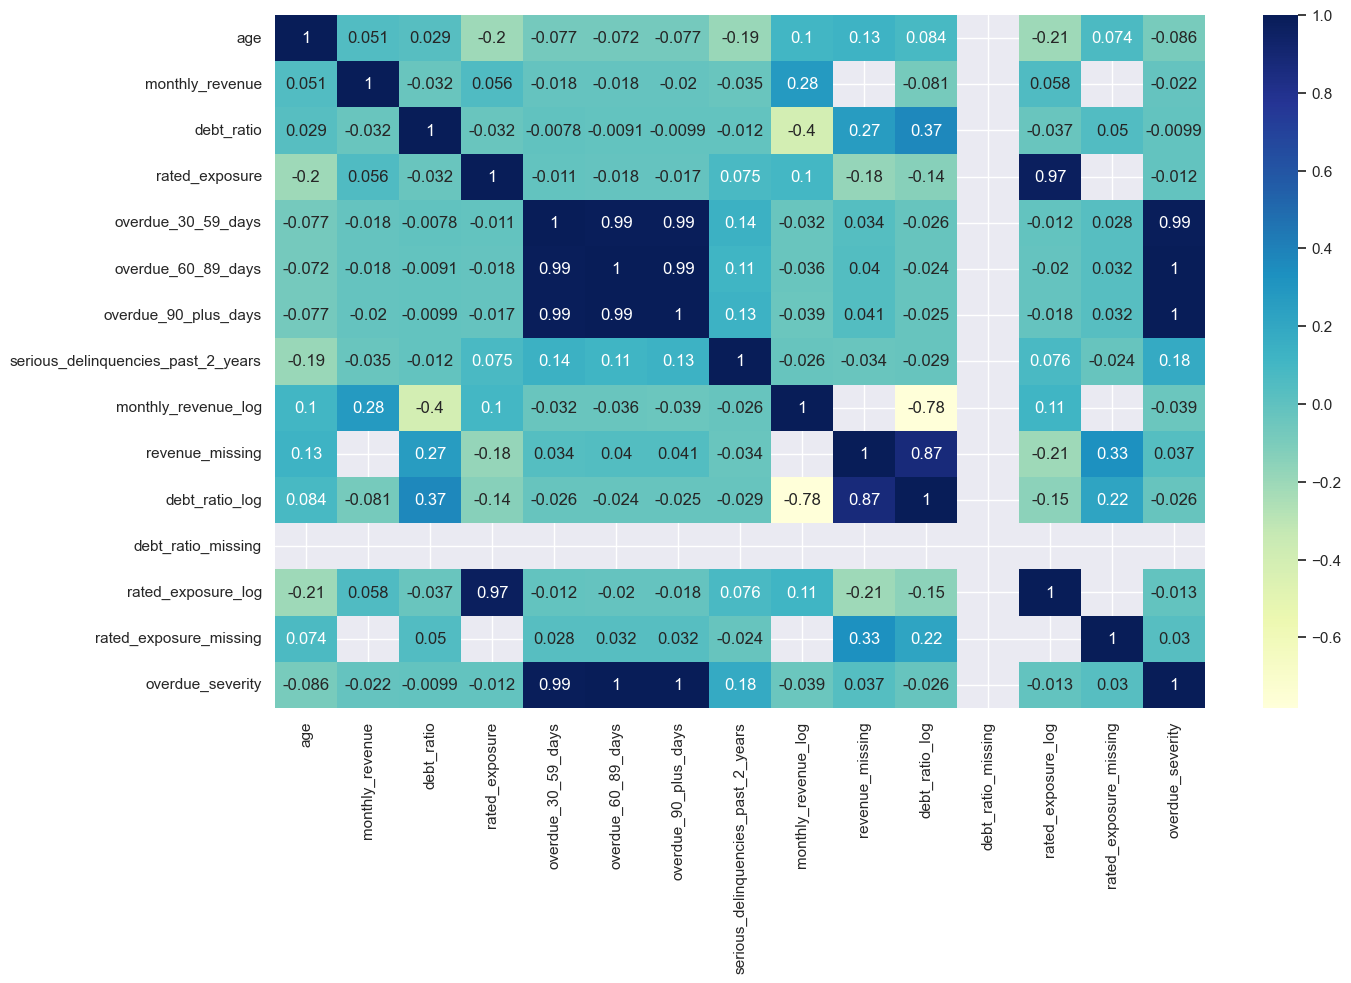

In [8]:
"""Seaborn and Line Plots"""
# plt.figure(figsize=(16,6))
# sns.lineplot(data=df['monthly_revenue']) # original

"""Line Plots"""
# plt.figure(figsize=(20,6))
# plt.title(current_var)
# sns.lineplot(data=df[current_var])

"""Bar Plots"""
# x_var = 'rated_exposure'
# y_var = 'age'
# plt.figure(figsize=(25,7))
# plt.title(f'{x_var} vs. {y_var}')
# sns.barplot(x=df[x_var], y=df[y_var])

"""Scatter Plots"""
# x_var = 'rated_exposure'
# y_var = 'age'
# plt.figure(figsize=(25,7))
# plt.title(f'{x_var} vs. {y_var}')
# sns.scatterplot(x=df[x_var], y=df[y_var])

"""Pie Graphs (Custom)"""
# plt.figure(figsize=(25,9))
# Plots.plot_age_ranges(df, 'age', title='% of Age Ranges')

"""Correlation Matrix"""
correlation_matrix = df.corr()
plt.figure(figsize=(15,9))
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu')
plt.show()

The describe() function was also added to provide quick descriptive statistics of the final dataframe.

In [9]:
df.describe()

,age,monthly_revenue,debt_ratio,rated_exposure,overdue_30_59_days,overdue_60_89_days,overdue_90_plus_days,serious_delinquencies_past_2_years,monthly_revenue_log,revenue_missing,debt_ratio_log,debt_ratio_missing,rated_exposure_log,rated_exposure_missing,overdue_severity
count,45063.000000,36420.000000,45063.000000,43946.000000,45063.000000,45063.000000,45063.000000,45063.000000,36420.000000,45063.000000,45063.000000,45063.000000,43946.000000,45063.000000,45063.000000
mean,51.210949,6452.263399,352.062688,0.789628,0.750993,0.505870,0.570712,0.222489,8.386983,0.191798,1.495795,0.000000,0.422022,0.024788,4.587311
std,14.651533,12638.167723,2467.556358,1.130813,6.184521,6.153609,6.173106,0.415922,1.307763,0.393720,2.597857,0.000000,0.537023,0.155479,37.234356
min,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,3286.000000,0.176373,0.000000,0.000000,0.000000,0.000000,0.000000,8.097731,0.000000,0.162436,0.000000,0.000000,0.000000,0.000000
50%,51.000000,5166.000000,0.373949,0.000000,0.000000,0.000000,0.000000,0.000000,8.550048,0.000000,0.317689,0.000000,0.000000,0.000000,0.000000
75%,62.000000,8000.000000,0.857027,1.000000,0.000000,0.000000,0.000000,0.000000,8.987322,0.000000,0.618977,0.000000,0.693147,0.000000,3.000000
max,107.000000,1794060.000000,326442.000000,10.000000,98.000000,98.000000,98.000000,1.000000,14.399992,1.000000,12.696011,0.000000,2.397895,1.000000,593.000000


The following code contains data transformations applied to the final dataframe to prepare it for analysis and visualization.

In [10]:
# Enforce monotonic severity for delinquencies
df = data_transformations.backfill_overdues(df, col_1='overdue_30_59_days', col_2='overdue_60_89_days', col_3='overdue_90_plus_days')